In [1]:
# to visualize data
import matplotlib.pyplot as plt

# to browse directories
import os

# to manage dataframes
import pandas as pd
import numpy as np

# to calculate the time to run the codes
from datetime import datetime

# the deep learning framework (TensorFlow)
import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0,DenseNet121,MobileNetV2,EfficientNetV2S
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
import shutil
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img, save_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import math

from sklearn.metrics import multilabel_confusion_matrix, classification_report, f1_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from pathlib import Path
from collections import Counter

SEED_VALUE = 42
np.random.seed(SEED_VALUE)
import random
random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

2025-12-18 21:19:03.896537: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-18 21:19:04.086537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766067544.159708    2043 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766067544.181759    2043 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766067544.348129    2043 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Data Preprocessing

## Total Data

* Train: 3899
* Validation: 1141
* Test: 598

In [3]:
CLASS_LIST = [
    "Crack",
    "CorrosionStain",
    "Efflorescence",
    "ExposedBars",
    "Spallation"
]

class_to_idx = {c: i for i, c in enumerate(CLASS_LIST)}
NUM_CLASSES = len(CLASS_LIST)

IMG_SIZE = (299, 299)   # Xception


In [4]:
label_dir = Path("dataset/building/train/Labels")

class_counter = Counter()
num_images = 0

for label_file in label_dir.glob("*.txt"):
    num_images += 1
    with open(label_file, "r") as f:
        labels = [l.strip() for l in f.readlines() if l.strip()]
        class_counter.update(labels)

print(f"Total train images: {num_images}")

for cls in CLASS_LIST:
    print(f"{cls:15s}: {class_counter[cls]}")


Total train images: 3899
Crack          : 1703
CorrosionStain : 1054
Efflorescence  : 517
ExposedBars    : 1059
Spallation     : 1287


In [5]:
def read_label_txt(label_path):
    y = np.zeros(NUM_CLASSES, dtype=np.float32)
    with open(label_path, "r") as f:
        for line in f:
            label = line.strip()
            if label in class_to_idx:
                y[class_to_idx[label]] = 1.0
    return y


In [6]:
def load_image_and_label(img_path, label_path):
    img = load_img(img_path, target_size=IMG_SIZE)
    img = img_to_array(img)
    img = tf.keras.applications.xception.preprocess_input(img)
    y = read_label_txt(label_path)
    return img, y


In [7]:
def build_file_pairs(root_dir):
    img_dir = Path(root_dir) / "Images"
    label_dir = Path(root_dir) / "Labels"

    pairs = []
    for img_path in sorted(img_dir.glob("*.jpg")):
        label_path = label_dir / (img_path.stem + ".txt")
        if label_path.exists():
            pairs.append((img_path, label_path))
    return pairs


In [8]:
train_pairs = build_file_pairs("dataset/building/train")
val_pairs   = build_file_pairs("dataset/building/valid")
test_pairs  = build_file_pairs("dataset/building/test")

In [9]:
def make_dataset(pairs, batch_size=16, shuffle=False):
    def gen():
        for img_p, lbl_p in pairs:
            yield load_image_and_label(img_p, lbl_p)

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(299, 299, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(NUM_CLASSES,), dtype=tf.float32),
        )
    )

    if shuffle:
        ds = ds.shuffle(512)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [10]:
class MultiLabelTopKAccuracy(tf.keras.metrics.Metric):
    def __init__(self, k=3, name="top_k_accuracy", **kwargs):
        super().__init__(name=name, **kwargs)
        self.k = k
        self.total = self.add_weight(name="total", initializer="zeros")
        self.correct = self.add_weight(name="correct", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # top-k predicted class indices
        top_k = tf.math.top_k(y_pred, k=self.k).indices  # (B, k)
        top_k = tf.cast(top_k, tf.int32)

        # convert y_true to int
        y_true = tf.cast(y_true, tf.int32)

        # gather true labels at top-k positions
        top_k_true = tf.gather(y_true, top_k, batch_dims=1)  # (B, k)

        # correct if any true label appears in top-k
        correct = tf.reduce_any(top_k_true > 0, axis=1)

        self.correct.assign_add(tf.reduce_sum(tf.cast(correct, tf.float32)))
        self.total.assign_add(tf.cast(tf.shape(y_true)[0], tf.float32))

    def result(self):
        return self.correct / self.total

    def reset_state(self):
        self.correct.assign(0)
        self.total.assign(0)

In [11]:
BATCH_SIZE = 32

train_ds = make_dataset(train_pairs, BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(val_pairs, BATCH_SIZE)
test_ds  = make_dataset(test_pairs, BATCH_SIZE)


I0000 00:00:1766067551.291608    2043 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [12]:
images, labels = next(iter(train_ds))

print(images.shape)   # (B, 299, 299, 3)
print(labels.shape)   # (B, 5)
print(labels[:3])


(32, 299, 299, 3)
(32, 5)
tf.Tensor(
[[0. 1. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]], shape=(3, 5), dtype=float32)


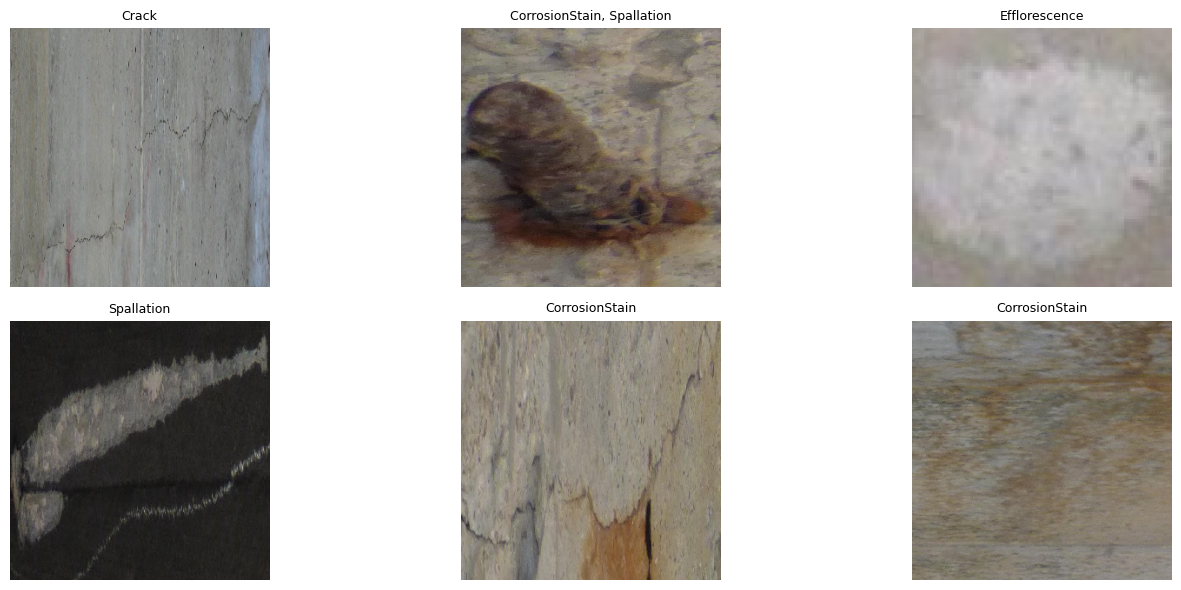

In [15]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(train_ds))

plt.figure(figsize=(15, 6))

for i in range(min(6, images.shape[0])):
    plt.subplot(2, 3, i + 1)

    # denormalize dari preprocess
    img = (images[i] + 1.0) * 127.5
    img = np.clip(img, 0, 255).astype(np.uint8)

    plt.imshow(img)
    plt.axis("off")

    active_labels = [
        CLASS_LIST[j] for j in range(len(CLASS_LIST))
        if labels[i][j] == 1
    ]

    plt.title(", ".join(active_labels), fontsize=9)

plt.tight_layout()
plt.show()


# Model Definition and Training

In [13]:
base_model = tf.keras.applications.Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3)
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.Dense(512, activation="relu")(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="sigmoid")(x)

model_xception = tf.keras.Model(base_model.input, outputs)


In [14]:
model_xception.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["binary_accuracy", tf.keras.metrics.AUC(multi_label=True), MultiLabelTopKAccuracy(k=3)]
)


In [15]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_model_xception.h5",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=5,
        min_lr=1e-6
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]


In [16]:
hist_xception = model_xception.fit(
    train_ds,
    callbacks=callbacks,
    validation_data=val_ds,
    epochs=50
)


Epoch 1/50


I0000 00:00:1765992979.612097   85356 service.cc:152] XLA service 0x7f6dd4002850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765992979.612139   85356 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2025-12-18 00:36:19.682150: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1765992980.336849   85356 cuda_dnn.cc:529] Loaded cuDNN version 91400
2025-12-18 00:36:23.278495: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3968', 204 bytes spill stores, 204 bytes spill loads

2025-12-18 00:36:23.439621: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fus

    121/Unknown 44s 154ms/step - auc: 0.7018 - binary_accuracy: 0.7594 - loss: 0.5218 - top_k_accuracy: 0.8698

2025-12-18 00:36:59.595455: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3975', 132 bytes spill stores, 132 bytes spill loads

2025-12-18 00:36:59.712693: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3968', 236 bytes spill stores, 236 bytes spill loads

2025-12-18 00:37:00.038777: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3968', 1012 bytes spill stores, 1012 bytes spill loads

2025-12-18 00:37:00.195182: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3975', 224 bytes spill stores, 224 bytes spill loads

2025-12-18 00:37:00.367667: I 

    122/Unknown 60s 290ms/step - auc: 0.7027 - binary_accuracy: 0.7597 - loss: 0.5212 - top_k_accuracy: 0.8701

...

2025-12-18 00:46:41.477809: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10989875127125051872
2025-12-18 00:46:41.477853: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4654878973546372288


122/122 ━━━━━━━━━━━━━━━━━━━━ 21s 157ms/step - auc: 0.9861 - binary_accuracy: 0.9503 - loss: 0.1461 - top_k_accuracy: 0.9989 - val_auc: 0.9238 - val_binary_accuracy: 0.8778 - val_loss: 0.3013 - val_top_k_accuracy: 0.9772 - learning_rate: 3.0000e-05
Epoch 25/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 24s 182ms/step - auc: 0.9866 - binary_accuracy: 0.9503 - loss: 0.1440 - top_k_accuracy: 0.9980 - val_auc: 0.9237 - val_binary_accuracy: 0.8778 - val_loss: 0.3017 - val_top_k_accuracy: 0.9772 - learning_rate: 3.0000e-05
Epoch 26/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 24s 180ms/step - auc: 0.9870 - binary_accuracy: 0.9529 - loss: 0.1416 - top_k_accuracy: 0.9981 - val_auc: 0.9237 - val_binary_accuracy: 0.8771 - val_loss: 0.3019 - val_top_k_accuracy: 0.9746 - learning_rate: 3.0000e-05
Epoch 27/50


2025-12-18 00:47:34.470910: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10989875127125051872
2025-12-18 00:47:34.470988: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4654878973546372288


122/122 ━━━━━━━━━━━━━━━━━━━━ 21s 154ms/step - auc: 0.9864 - binary_accuracy: 0.9506 - loss: 0.1449 - top_k_accuracy: 0.9992 - val_auc: 0.9236 - val_binary_accuracy: 0.8785 - val_loss: 0.3005 - val_top_k_accuracy: 0.9746 - learning_rate: 3.0000e-05


2025-12-18 00:47:55.457312: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10989875127125051872
2025-12-18 00:47:55.457360: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4654878973546372288


In [ ]:
def build_vanilla_cnn(hp):
    inputs = layers.Input(shape=(299, 299, 3))
    x = inputs

    for i in range(hp.Int("num_blocks", 2, 5)):
        x = layers.Conv2D(
            filters=hp.Choice(f"filters_{i}", [32, 64, 128]),
            kernel_size=hp.Choice(f"kernel_{i}", [3, 5]),
            padding="same",
            activation="relu"
        )(x)

        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

        if hp.Boolean(f"dropout_{i}"):
            x = layers.Dropout(hp.Float(f"drop_rate_{i}", 0.2, 0.5))(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        hp.Choice("dense_units", [128, 256, 512]),
        activation="relu"
    )(x)

    x = layers.Dropout(hp.Float("final_dropout", 0.3, 0.6))(x)

    outputs = layers.Dense(5, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Float("lr", 1e-5, 1e-3, sampling="log")
        ),
        loss="binary_crossentropy",
        metrics=["binary_accuracy", tf.keras.metrics.AUC(multi_label=True), MultiLabelTopKAccuracy(k=3)]
    )

    return model


In [22]:
tuner = kt.Hyperband(
    build_vanilla_cnn,
    objective="val_binary_accuracy",
    max_epochs=5,
    factor=3,
    directory="tuner_logs",
    project_name="building_damage_vanilla_cnn"
)

Reloading Tuner from tuner_logs/building_damage_vanilla_cnn/tuner0.json


In [23]:
tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Trial 29 Complete [00h 07m 00s]
val_binary_accuracy: 0.8292726278305054

Best val_binary_accuracy So Far: 0.8387380838394165
Total elapsed time: 02h 17m 03s

Search: Running Trial #30

Value             |Best Value So Far |Hyperparameter
3                 |5                 |num_blocks
32                |32                |filters_0
5                 |5                 |kernel_0
True              |False             |dropout_0
128               |64                |filters_1
5                 |3                 |kernel_1
False             |True              |dropout_1
128               |512               |dense_units
0.57012           |0.46198           |final_dropout
0.00010961        |0.00054182        |lr
0.4517            |0.206             |drop_rate_0
64                |64                |filters_2
3                 |5                 |kernel_2
True              |False             |dropout_2
32                |64                |filters_3
3                 |3                 |kerne

KeyboardInterrupt: 

In [24]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

/home/anton/deep-learning/venv-tf/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 299, 299, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 299, 299, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 149, 149, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 149, 149, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 74, 74, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 74, 74, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 18, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 18, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,56

 Total params: 234,245 (915.02 KB)

 Trainable params: 233,669 (912.77 KB)

 Non-trainable params: 576 (2.25 KB)

In [25]:
history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
    122/Unknown 29s 147ms/step - auc: 0.8845 - binary_accuracy: 0.8420 - loss: 0.3549 - top_k_accuracy: 0.9534

2025-12-18 01:30:37.874568: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10989875127125051872
2025-12-18 01:30:37.874619: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4654878973546372288


122/122 ━━━━━━━━━━━━━━━━━━━━ 35s 197ms/step - auc: 0.8845 - binary_accuracy: 0.8420 - loss: 0.3549 - top_k_accuracy: 0.9534 - val_auc: 0.8834 - val_binary_accuracy: 0.8356 - val_loss: 0.3630 - val_top_k_accuracy: 0.9571 - learning_rate: 5.4182e-04
Epoch 2/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 25s 183ms/step - auc: 0.8974 - binary_accuracy: 0.8507 - loss: 0.3405 - top_k_accuracy: 0.9577 - val_auc: 0.8530 - val_binary_accuracy: 0.8065 - val_loss: 0.4380 - val_top_k_accuracy: 0.9483 - learning_rate: 5.4182e-04
Epoch 3/50


2025-12-18 01:31:08.465531: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10989875127125051872
2025-12-18 01:31:08.465573: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4654878973546372288


122/122 ━━━━━━━━━━━━━━━━━━━━ 24s 178ms/step - auc: 0.8957 - binary_accuracy: 0.8488 - loss: 0.3412 - top_k_accuracy: 0.9539 - val_auc: 0.8673 - val_binary_accuracy: 0.8021 - val_loss: 0.4112 - val_top_k_accuracy: 0.9649 - learning_rate: 5.4182e-04
Epoch 4/50


...

2025-12-18 01:42:57.611802: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10989875127125051872
2025-12-18 01:42:57.611845: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4654878973546372288


122/122 ━━━━━━━━━━━━━━━━━━━━ 24s 179ms/step - auc: 0.9598 - binary_accuracy: 0.9108 - loss: 0.2146 - top_k_accuracy: 0.9901 - val_auc: 0.9221 - val_binary_accuracy: 0.8699 - val_loss: 0.3121 - val_top_k_accuracy: 0.9693 - learning_rate: 4.8763e-05
Epoch 34/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 21s 154ms/step - auc: 0.9600 - binary_accuracy: 0.9098 - loss: 0.2145 - top_k_accuracy: 0.9833 - val_auc: 0.9205 - val_binary_accuracy: 0.8720 - val_loss: 0.3153 - val_top_k_accuracy: 0.9728 - learning_rate: 4.8763e-05
Epoch 35/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 24s 153ms/step - auc: 0.9633 - binary_accuracy: 0.9128 - loss: 0.2089 - top_k_accuracy: 0.9873 - val_auc: 0.9215 - val_binary_accuracy: 0.8706 - val_loss: 0.3143 - val_top_k_accuracy: 0.9720 - learning_rate: 4.8763e-05
Epoch 36/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 24s 177ms/step - auc: 0.9627 - binary_accuracy: 0.9074 - loss: 0.2107 - top_k_accuracy: 0.9894 - val_auc: 0.9199 - val_binary_accuracy: 0.8706 - val_loss: 0.3185 - val_top_k_accuracy: 0.9746 

2025-12-18 01:45:38.816311: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10989875127125051872
2025-12-18 01:45:38.816354: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4654878973546372288


122/122 ━━━━━━━━━━━━━━━━━━━━ 21s 156ms/step - auc: 0.9671 - binary_accuracy: 0.9159 - loss: 0.1993 - top_k_accuracy: 0.9888 - val_auc: 0.9222 - val_binary_accuracy: 0.8685 - val_loss: 0.3136 - val_top_k_accuracy: 0.9667 - learning_rate: 1.4629e-05
Epoch 41/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 24s 180ms/step - auc: 0.9655 - binary_accuracy: 0.9110 - loss: 0.2039 - top_k_accuracy: 0.9896 - val_auc: 0.9222 - val_binary_accuracy: 0.8698 - val_loss: 0.3133 - val_top_k_accuracy: 0.9667 - learning_rate: 1.4629e-05


2025-12-18 01:46:24.112828: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10989875127125051872
2025-12-18 01:46:24.112876: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4654878973546372288


# Model Evaluation

### Model final AUC, Binary Acc, Loss, and top_k_acc

In [39]:
model_xception.evaluate(test_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 370ms/step - auc: 0.9304 - binary_accuracy: 0.8859 - loss: 0.2613 - top_k_accuracy: 0.9857


/home/anton/deep-learning/venv-tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[0.29249563813209534, 0.8829431533813477, 0.9295088052749634, 0.97826087474823]

In [26]:
best_model.evaluate(test_ds)

     18/Unknown 3s 156ms/step - auc: 0.9215 - binary_accuracy: 0.8840 - loss: 0.2851 - top_k_accuracy: 0.9808

2025-12-18 01:46:27.872574: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_211', 224 bytes spill stores, 224 bytes spill loads

2025-12-18 01:46:27.903873: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_211', 4 bytes spill stores, 4 bytes spill loads

2025-12-18 01:46:28.096219: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_211', 132 bytes spill stores, 132 bytes spill loads

2025-12-18 01:46:28.145842: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_211', 264 bytes spill stores, 264 bytes spill loads



19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 333ms/step - auc: 0.9208 - binary_accuracy: 0.8826 - loss: 0.2900 - top_k_accuracy: 0.9806


[0.3338167667388916, 0.8692307472229004, 0.9143983125686646, 0.97826087474823]

In [27]:
def get_predictions(model, dataset):
    y_true = []
    y_pred_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_pred_prob.append(probs)
        y_true.append(labels.numpy())

    y_true = np.vstack(y_true)
    y_pred_prob = np.vstack(y_pred_prob)

    return y_true, y_pred_prob


### Classification Report (Non optimized threshold)

In [28]:
y_true_x, y_prob_x = get_predictions(model_xception, test_ds)

y_pred_x = (y_prob_x >= 0.5).astype(int)

print("XCEPTION CLASSIFICATION REPORT")
print(classification_report(
    y_true_x,
    y_pred_x,
    target_names=CLASS_LIST,
    zero_division=0
))


2025-12-18 01:46:43.320664: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1013', 236 bytes spill stores, 236 bytes spill loads

2025-12-18 01:46:43.506391: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1013', 4388 bytes spill stores, 4232 bytes spill loads

2025-12-18 01:46:43.628306: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1013', 1012 bytes spill stores, 1012 bytes spill loads

2025-12-18 01:46:46.402646: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-18 01:46:46.548962: E exter

XCEPTION CLASSIFICATION REPORT
                precision    recall  f1-score   support

         Crack       0.89      0.84      0.86       286
CorrosionStain       0.71      0.67      0.69       153
 Efflorescence       0.88      0.62      0.72        94
   ExposedBars       0.88      0.82      0.85       175
    Spallation       0.83      0.75      0.79       208

     micro avg       0.84      0.76      0.80       916
     macro avg       0.84      0.74      0.78       916
  weighted avg       0.84      0.76      0.80       916
   samples avg       0.80      0.79      0.77       916



In [29]:
y_true_cnn, y_prob_cnn = get_predictions(best_model, test_ds)

y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

print("VANILLA CNN (NAS) CLASSIFICATION REPORT")
print(classification_report(
    y_true_cnn,
    y_pred_cnn,
    target_names=CLASS_LIST,
    zero_division=0
))

VANILLA CNN (NAS) CLASSIFICATION REPORT
                precision    recall  f1-score   support

         Crack       0.83      0.81      0.82       286
CorrosionStain       0.76      0.67      0.71       153
 Efflorescence       0.81      0.62      0.70        94
   ExposedBars       0.89      0.78      0.83       175
    Spallation       0.83      0.66      0.73       208

     micro avg       0.83      0.73      0.77       916
     macro avg       0.82      0.71      0.76       916
  weighted avg       0.83      0.73      0.77       916
   samples avg       0.77      0.75      0.74       916



In [30]:
def f1_summary(y_true, y_pred, name):
    print(f"\n{name}")
    print("Micro F1 :", f1_score(y_true, y_pred, average="micro"))
    print("Macro F1 :", f1_score(y_true, y_pred, average="macro"))
    print("Weighted :", f1_score(y_true, y_pred, average="weighted"))


In [31]:
f1_summary(y_true_x, y_pred_x, "XCEPTION")
f1_summary(y_true_cnn, y_pred_cnn, "VANILLA CNN (NAS)")


XCEPTION
Micro F1 : 0.8
Macro F1 : 0.7819510540457383
Weighted : 0.799105106860668

VANILLA CNN (NAS)
Micro F1 : 0.7728065078442766
Macro F1 : 0.7585270997195472
Weighted : 0.7713200264405289


In [32]:
from sklearn.metrics import multilabel_confusion_matrix

cm_x = multilabel_confusion_matrix(y_true_x, y_pred_x)
cm_cnn = multilabel_confusion_matrix(y_true_cnn, y_pred_cnn)

for i, cls in enumerate(CLASS_LIST):
    print(f"\nXCEPTION – {cls}")
    print(cm_x[i])

    print(f"\nCNN NAS – {cls}")
    print(cm_cnn[i])



XCEPTION – Crack
[[281  31]
 [ 46 240]]

CNN NAS – Crack
[[265  47]
 [ 55 231]]

XCEPTION – CorrosionStain
[[402  43]
 [ 50 103]]

CNN NAS – CorrosionStain
[[412  33]
 [ 50 103]]

XCEPTION – Efflorescence
[[496   8]
 [ 36  58]]

CNN NAS – Efflorescence
[[490  14]
 [ 36  58]]

XCEPTION – ExposedBars
[[403  20]
 [ 32 143]]

CNN NAS – ExposedBars
[[406  17]
 [ 39 136]]

XCEPTION – Spallation
[[358  32]
 [ 52 156]]

CNN NAS – Spallation
[[361  29]
 [ 71 137]]


### Optimized Threshold

In [36]:
def optimize_thresholds(y_true, y_prob):
    thresholds = []
    for i in range(y_true.shape[1]):
        best_t, best_f1 = 0.5, 0
        for t in np.linspace(0.1, 0.9, 17):
            f1 = f1_score(y_true[:, i], (y_prob[:, i] >= t))
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        thresholds.append(best_t)
    return thresholds

thr_x = optimize_thresholds(y_true_x, y_prob_x)
thr_cnn = optimize_thresholds(y_true_cnn, y_prob_cnn)

print("Xception thresholds:", thr_x)
print("CNN NAS thresholds:", thr_cnn)

Xception thresholds: [np.float64(0.5), np.float64(0.4), np.float64(0.30000000000000004), np.float64(0.55), np.float64(0.35)]
CNN NAS thresholds: [np.float64(0.30000000000000004), np.float64(0.4), np.float64(0.35), np.float64(0.30000000000000004), np.float64(0.4)]


In [38]:
y_pred_x_opt = (y_prob_x >= thr_x).astype(int)
y_pred_cnn_opt = (y_prob_cnn >= thr_cnn).astype(int)

f1_summary(y_true_x, y_pred_x_opt, "XCEPTION (OPT)")
f1_summary(y_true_cnn, y_pred_cnn_opt, "CNN NAS (OPT)")


XCEPTION (OPT)
Micro F1 : 0.8091603053435115
Macro F1 : 0.7992557178975985
Weighted : 0.8110728315194573

CNN NAS (OPT)
Micro F1 : 0.7897271268057785
Macro F1 : 0.7775836812093783
Weighted : 0.7886370319906774


In [ ]:
y_pred_x_opt = (y_prob_x >= thr_x).astype(int)

print("XCEPTION CLASSIFICATION REPORT")
print(classification_report(
    y_true_x,
    y_pred_x_opt,
    target_names=CLASS_LIST,
    zero_division=0
))

XCEPTION CLASSIFICATION REPORT
                precision    recall  f1-score   support

         Crack       0.89      0.84      0.86       286
CorrosionStain       0.66      0.75      0.71       153
 Efflorescence       0.81      0.74      0.78        94
   ExposedBars       0.90      0.81      0.85       175
    Spallation       0.76      0.85      0.80       208

     micro avg       0.81      0.81      0.81       916
     macro avg       0.80      0.80      0.80       916
  weighted avg       0.82      0.81      0.81       916
   samples avg       0.80      0.83      0.80       916



In [37]:
y_true_cnn, y_prob_cnn = get_predictions(best_model, test_ds)

y_pred_cnn = (y_prob_cnn >= thr_cnn).astype(int)

print("VANILLA CNN (NAS) CLASSIFICATION REPORT")
print(classification_report(
    y_true_cnn,
    y_pred_cnn,
    target_names=CLASS_LIST,
    zero_division=0
))


VANILLA CNN (NAS) CLASSIFICATION REPORT
                precision    recall  f1-score   support

         Crack       0.78      0.89      0.83       286
CorrosionStain       0.71      0.75      0.73       153
 Efflorescence       0.74      0.71      0.73        94
   ExposedBars       0.84      0.86      0.85       175
    Spallation       0.77      0.73      0.75       208

     micro avg       0.77      0.81      0.79       916
     macro avg       0.77      0.79      0.78       916
  weighted avg       0.77      0.81      0.79       916
   samples avg       0.79      0.83      0.79       916



## Training Plot

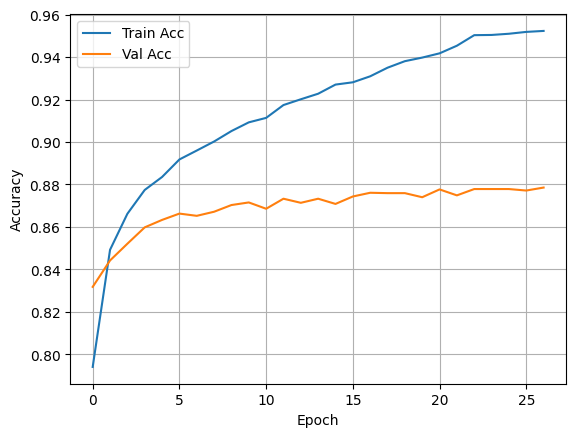

In [41]:
plt.figure()
plt.plot(hist_xception.history['binary_accuracy'], label='Train Acc')
plt.plot(hist_xception.history['val_binary_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


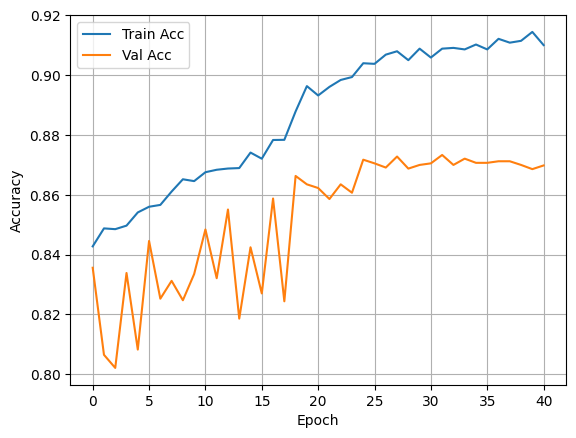

In [ ]:
plt.figure()
plt.plot(history.history['binary_accuracy'], label='Train Acc')
plt.plot(history.history['val_binary_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


##  Precision Recall Plot

In [51]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    y_true.append(y_batch.numpy())
    y_pred.append(model_xception.predict(x_batch, verbose=0))

y_true = np.vstack(y_true)
y_pred_xception = np.vstack(y_pred)

In [53]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    y_true.append(y_batch.numpy())
    y_pred.append(best_model.predict(x_batch, verbose=0))

y_true = np.vstack(y_true)
y_pred_cnn = np.vstack(y_pred)

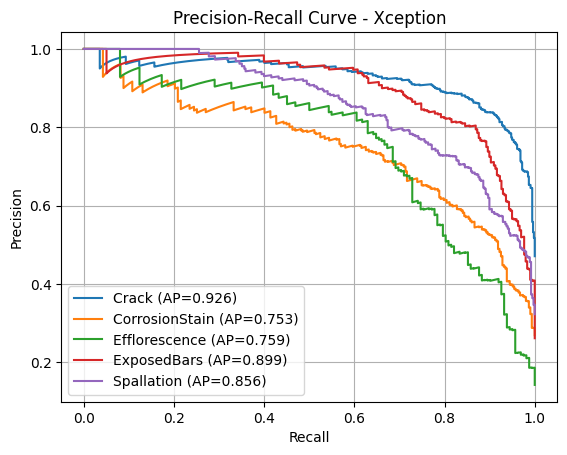

In [ ]:
for i, cls in enumerate(CLASS_LIST):
    p, r, _ = precision_recall_curve(y_true[:, i], y_pred_xception[:, i])
    ap = average_precision_score(y_true[:, i], y_pred_xception[:, i])
    plt.plot(r, p, label=f"{cls} (AP={ap:.3f})")

plt.title("Precision-Recall Curve - Xception")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

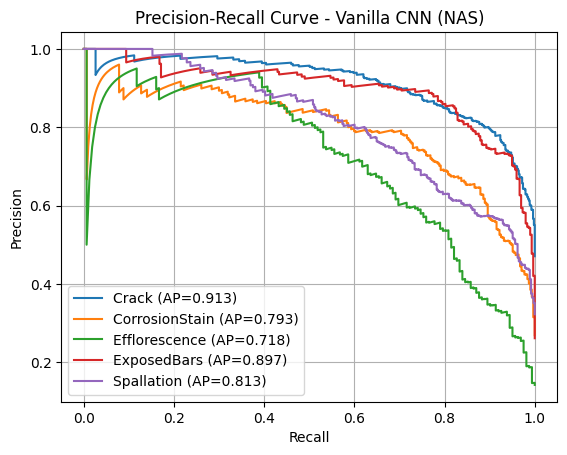

In [57]:
for i, cls in enumerate(CLASS_LIST):
    p, r, _ = precision_recall_curve(y_true[:, i], y_pred_cnn[:, i])
    ap = average_precision_score(y_true[:, i], y_pred_cnn[:, i])
    plt.plot(r, p, label=f"{cls} (AP={ap:.3f})")

plt.title("Precision-Recall Curve - Vanilla CNN (NAS)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()


## ROC Plot

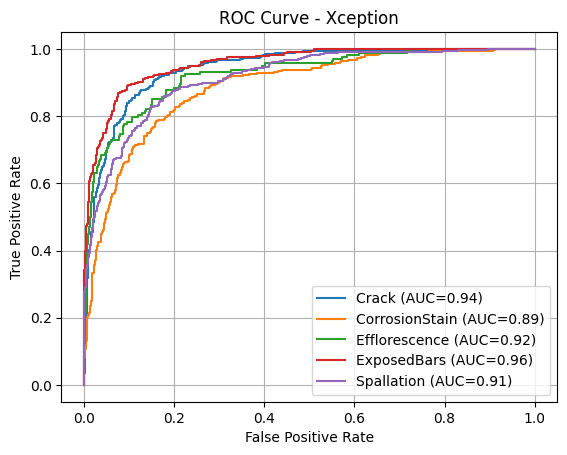

In [61]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    y_true.append(y_batch.numpy())
    y_pred.append(model_xception.predict(x_batch, verbose=0))

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

for i, cls in enumerate(CLASS_LIST):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

plt.title("ROC Curve - Xception")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


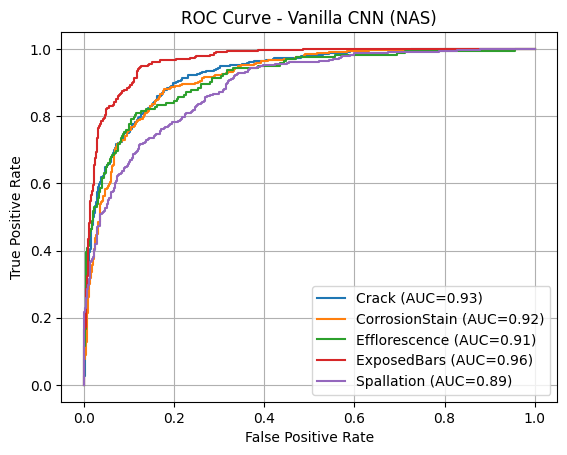

In [62]:
y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    y_true.append(y_batch.numpy())
    y_pred.append(best_model.predict(x_batch, verbose=0))

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

for i, cls in enumerate(CLASS_LIST):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.2f})")

plt.title("ROC Curve - Vanilla CNN (NAS)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


## Single Precision Recall Plot

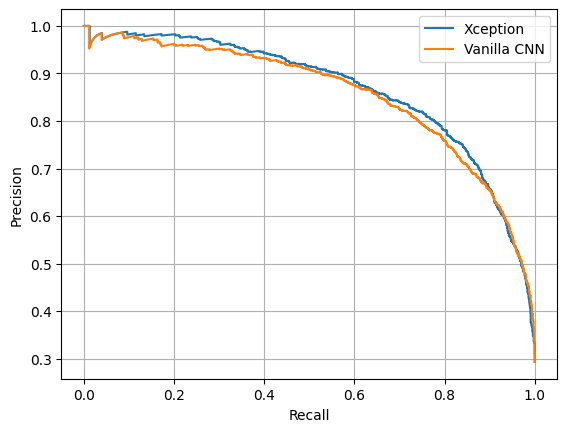

In [55]:
# Xception
p_x, r_x, _ = precision_recall_curve(y_true.ravel(), y_pred_xception.ravel())

# Vanilla CNN
p_v, r_v, _ = precision_recall_curve(y_true.ravel(), y_pred_cnn.ravel())

plt.figure()
plt.plot(r_x, p_x, label="Xception")
plt.plot(r_v, p_v, label="Vanilla CNN")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()
